# `Практикум по программированию на языке Python`

## `Задание 01. Полносвязная нейронная сеть на numpy`.

#### Фамилия, имя: 

Дата выдачи: <span style="color:red">__13 февраля__</span>.

Мягкий дедлайн: <span style="color:red">__28 февраля 05:00__</span>.

Стоимость: __10 баллов__ (основная часть заданий) + __3 балла__ (дополнительные задания).

<span style="color:red">__В ноутбуке все клетки должны выполняться без ошибок при последовательном их выполнении.__</span>

#### `Москва, 2025`

In [1]:
import numpy as np

## `Теоретическая часть (3 балла)`

В этом блоке вам нужно решить 3 задания.

### `Задание 1. Градиенты для слоя Batch normalization (1.5 балла)`

Рассмотрим слой Batch normalization. Пусть на вход этого слоя был подан батч из $n$ объектов, при этом у всех объектов по 1 признаку. Представим вход BN слоя в виде $X \in \mathbb{R}^{n \times 1}$.

Тогда в этом слое производятся следующие вычисления:

$$ \mu = \frac1n \sum_{i=1}^{n} X_i $$

$$ \sigma^2 = \frac1n \sum_{i=1}^{n} \left( X_i - \mu \right) ^2 $$

$$ \tilde{y_i} = \frac{X_i - \mu}{\sqrt{\sigma^2 + \varepsilon}} $$

$$ y_i = \gamma \tilde{y_i} + \delta $$

Выходом BN слоя является $y_i$, а $\gamma,\delta\in\mathbb{R}$ — параметры, которые подбираются во время обучения вместе с другими параметрами нейронной сети (наряду, например, с весами линейного слоя).

Рассмотрим нейронную сеть, в которой есть BN слой. Предположим, что вычисления в нейронной сети завершаются подсчетом функции потерь $\mathcal{L}$. Пусть мы выполнили прямой проход по нейронной сети и сейчас делаем обратный проход с помощью метода обратного распространения ошибки. Пусть BN слою пришел градиент функции потерь по выходу BN слоя ($\nabla_{y} \mathcal{L}$).

В этом задании вам нужно записать вычисление градиента функции потерь по параметрам слоя BN $\gamma$ и $\delta$ ($\nabla_{\gamma} \mathcal{L}$, $\nabla_{\delta} \mathcal{L}$) через $\nabla_{y} \mathcal{L}$, а также вам нужно записать вычисление градиента функции потерь по входу слоя BN $X$ ($\nabla_{X} \mathcal{L}$) через $\nabla_{y} \mathcal{L}$.

Хочу заметить, в данном задании мы рассматриваем объекты всего с 1 признаком, чтобы упростить выкладки.

__Ваше решение:__
$$
\mathcal{L} = \mathcal{L}(y_1,\dots,y_n), \qquad y_i = \gamma \tilde{y}_i + \delta
$$

Тогда дифференциал функции потерь равен

$$
d\mathcal{L} = \sum_{i=1}^{n} \frac{\partial \mathcal{L}}{\partial y_i} \, dy_i
$$

Найдём дифференциал $y_i$. Поскольку

$$
y_i = \gamma \tilde{y}_i + \delta
$$

получаем

$$
dy_i =
\frac{\partial y_i}{\partial \gamma} d\gamma +
\frac{\partial y_i}{\partial \delta} d\delta +
\frac{\partial y_i}{\partial \tilde{y}_i} d\tilde{y}_i = \tilde{y}_i d\gamma + d\delta + \gamma d\tilde{y}_i
$$

Подставляя это в выражение для $d\mathcal{L}$, получаем

$$
d\mathcal{L}
=
\sum_{i=1}^{n}
\frac{\partial \mathcal{L}}{\partial y_i}
\left(
\tilde{y}_i d\gamma + d\delta + \gamma d\tilde{y}
\right) = \nabla_y \mathcal{L} (\tilde{y}d\gamma + d\delta + \gamma d\tilde{y})
$$


$$
d\mathcal{L}
=
\langle\nabla_y \mathcal{L}\tilde{y},d\gamma\rangle
+
\langle\nabla_y \mathcal{L},d\delta\rangle
+
\langle\nabla_y \mathcal{L} \gamma, d\tilde{y}\rangle
$$
$$
\nabla_{\gamma}\mathcal{L}
=
\nabla_y \mathcal{L}\cdot\tilde{y}
$$

$$
\nabla_{\delta}\mathcal{L}
=
\nabla_y \mathcal{L}\cdot 1
$$

$$
\nabla_{\tilde{y}}\mathcal{L}
=
\nabla_y \mathcal{L}\cdot \gamma
=
\nabla_X \tilde y \; \mathcal L
=
\nabla_X \left(\frac{X-\mu}{\sqrt{\sigma^2+\varepsilon}}\right)\mathcal L \gamma
$$

$$
=
\frac{\gamma}{\sqrt{\sigma^2+\varepsilon}}
\left(
\nabla_y\mathcal L
-
\frac{1}{n}(\nabla_y\mathcal L\cdot 1)\,1
-
\frac{1}{n}(\nabla_y\mathcal L\cdot \tilde y)\,\tilde y
\right)
$$

$$
\nabla_X\mathcal L
=
\frac{\gamma}{\sqrt{\sigma^2+\varepsilon}}
\left(
\nabla_y\mathcal L
-
\frac{1}{n}(\nabla_y\mathcal L\cdot 1)\,1
-
\frac{1}{n}(\nabla_y\mathcal L\cdot \tilde y)\,\tilde y
\right)
$$

$$
\nabla_{\tilde{y}}\mathcal{L}
=
\nabla_y \mathcal{L}\cdot \gamma
$$

$$
\tilde y=\frac{X-\mu}{\sqrt{\sigma^2+\varepsilon}}
$$


$$ \mu = \frac1n \sum_{i=1}^{n} X_i $$

$$ \sigma^2 = \frac1n \sum_{i=1}^{n} \left( X_i - \mu \right) ^2 $$

$$
d\tilde y
=
d\left(\frac{X-\mu}{\sqrt{\sigma^2+\varepsilon}}\right)
=
\frac{dX-d\mu}{\sqrt{\sigma^2+\varepsilon}}
-
\frac{X-\mu}{2(\sigma^2+\varepsilon)^{3/2}}\,d\sigma^2
$$

$$
d\mu=\frac1n\,1^T dX
$$

$$
d\sigma^2=\frac{2}{n}(X-\mu)^T dX
$$

$$
\Rightarrow
\quad
d\tilde y
=
\frac{1}{\sqrt{\sigma^2+\varepsilon}}
\left(
dX-\frac1n(1^T dX)\,1-\frac1n(\tilde y^T dX)\,\tilde y
\right)
$$

$$
d\mathcal L
=
\langle \nabla_{\tilde y}\mathcal L,d\tilde y\rangle
$$

$$
=
\left\langle
\gamma \nabla_y\mathcal L,
\frac{1}{\sqrt{\sigma^2+\varepsilon}}
\left(
dX-\frac1n(1^T dX)\,1-\frac1n(\tilde y^T dX)\,\tilde y
\right)
\right\rangle
$$

$$
=
\left\langle
\frac{\gamma}{\sqrt{\sigma^2+\varepsilon}}
\left(
\nabla_y\mathcal L
-
\frac1n(\nabla_y\mathcal L\cdot 1)\,1
-
\frac1n(\nabla_y\mathcal L\cdot \tilde y)\,\tilde y
\right),
dX
\right\rangle
$$

$$
\Rightarrow
\quad
\nabla_X\mathcal L
=
\frac{\gamma}{\sqrt{\sigma^2+\varepsilon}}
\left(
\nabla_y\mathcal L
-
\frac1n(\nabla_y\mathcal L\cdot 1)\,1
-
\frac1n(\nabla_y\mathcal L\cdot \tilde y)\,\tilde y
\right)
$$

### `Задание 2. Вывод инициализации весов линейного слоя при использовании ReLU в качестве функции активации (1 балл)`

Рассмотрим полносвязную нейронную сеть с функцией активации $g(y)$. Пусть сеть состоит из $L$ слоев и размер входа слоя $l$ равен $n_l\ \ (l = \overline{1, L})$.

Обозначим за $x^l \in \mathbb{R}^{n_{l}}$ вход слоя $l$, за $y^l \in \mathbb{R}^{n_{l+1}}$ — выход слоя $l$, за $W^l \in \mathbb{R}^{n_{l+1} \times n_{l}}$ — веса слоя $l$, за $b^l \in \mathbb{R}^{n_{l+1}}$ — вектор сдвига слоя $l$.

Тогда
$$y^l = W^l x^l + b^l,$$
$$x^{l+1} = g(y^l).$$

На паре вы выводили хорошую инициализацию для линейного слоя в случае, когда в качестве функции активации $g(y)$ в нейронной сети используется гиперболический тангенс $g(y) = \tanh(y)$. Сейчас вам нужно сделать подобный вывод для случая, когда в сети в качестве функций активации используется $g(y) = ReLU(y) = \max(0, y)$.

Сделаем следующие предположения насчет того, как распределены веса $W^l$, вектор сдвига $b^l$, входной вектор $x^l$, выходной вектор $y^l$ линейного слоя и градиенты функции потерь $\frac{\partial L}{\partial y^{l}}$ $(l = \overline{1, L}$):

1. Все компоненты в $W^l$ распределены одинаково и независимо друг от друга;
2. Все компоненты в $y^l$ распределены одинаково и независимо друг от друга;
3. Все компоненты в $x^l$ распределены одинаково и независимо друг от друга;
4. Все компоненты в $\frac{\partial L}{\partial y^{l}}$ распределены одинаково и независимо друг от друга;
5. Все компоненты в $W^l$ и все компоненты в $x^l$ независимы друг от друга;
6. Все компоненты в $W^l$ имеют четную плотность распределения (то есть симметричную относительно нуля: $p_{W^l}(-x) = p_{W^l}(x)$);
7. Все компоненты в $W^l$ имеют конечное матожидание;
8. Вектор $b^l$ инициализирован нулями.


Подсказки:
1. Из пунктов 6 и 7 следует, что все компоненты в $W^l$ имеют нулевое среднее ($\mathbb{E} W^l_{ij} = 0\ \ \forall i = \overline{1, n_{l+1}}, j = \overline{1, n_{l}}$) (докажите);
2. Из пунктов 6 и 7 следует, что все компоненты в $y^l$ имеют нулевое среднее и четную плотность распределения (докажите).

__Ваше решение:__

$$
\text{Так как плотность распределения } W^l_{ij} \text{ чётная,}
\qquad
p_{W^l}(-x)=p_{W^l}(x),
$$

$$
\mathbb E W^l_{ij}
=
\int_{-\infty}^{+\infty} x\,p_{W^l}(x)\,dx
=
0.
$$

$$
\text{Следовательно,}
\qquad
\mathbb E y_i^l
=
\mathbb E \sum_{j=1}^{n_l} W^l_{ij}x_j^l
=
\sum_{j=1}^{n_l}\mathbb E W^l_{ij}\,\mathbb E x_j^l
=
0.
$$

$$
\text{Так как } b^l=0,\text{ то}
\qquad
y_i^l=\sum_{j=1}^{n_l}W^l_{ij}x_j^l.
$$

$$
\mathrm{Var}(y_i^l)
=
\mathrm{Var}\left(\sum_{j=1}^{n_l}W^l_{ij}x_j^l\right)
=
\sum_{j=1}^{n_l}\mathrm{Var}(W^l_{ij}x_j^l).
$$

$$
\mathrm{Var}(W^l_{ij}x_j^l)
=
\mathbb E (W^l_{ij})^2\,\mathbb E (x_j^l)^2
=
\mathrm{Var}(W^l_{ij})\,\mathbb E (x_j^l)^2.
$$

$$
\text{Тогда}
\qquad
\mathrm{Var}(y_i^l)
=
n_l\,\mathrm{Var}(W^l_{ij})\,\mathbb E (x_j^l)^2.
$$

$$
\text{Так как }
x_i^{l+1}=\mathrm{ReLU}(y_i^l)=\max(0,y_i^l),
$$

$$
\mathbb E (x_i^{l+1})^2
=
\mathbb E (\mathrm{ReLU}(y_i^l))^2.
$$

$$
\text{Поскольку распределение } y_i^l \text{ симметрично относительно нуля,}
$$

$$
\mathbb E (\mathrm{ReLU}(y_i^l))^2
=
\frac12 \mathbb E (y_i^l)^2.
$$

$$
\text{Но } \mathbb E y_i^l=0,\text{ значит}
\qquad
\mathbb E (y_i^l)^2=\mathrm{Var}(y_i^l).
$$

$$
\Rightarrow
\qquad
\mathbb E (x_i^{l+1})^2
=
\frac12\,\mathrm{Var}(y_i^l).
$$

$$
\text{Подставляя выражение для } \mathrm{Var}(y_i^l),\text{ получаем}
$$

$$
\mathbb E (x_i^{l+1})^2
=
\frac12\,n_l\,\mathrm{Var}(W^l_{ij})\,\mathbb E (x_j^l)^2.
$$

$$
\text{Чтобы дисперсия активаций сохранялась по слоям, потребуем}
\qquad
\mathbb E (x_i^{l+1})^2=\mathbb E (x_j^l)^2.
$$

$$
\text{Тогда}
\qquad
\frac12\,n_l\,\mathrm{Var}(W^l_{ij})=1.
$$

$$
\Rightarrow
\qquad
\mathrm{Var}(W^l_{ij})=\frac{2}{n_l}.
$$

$$
\text{Следовательно, хорошая инициализация для ReLU имеет вид}
\qquad
W^l_{ij}\sim \mathcal N\left(0,\frac{2}{n_l}\right).
$$

### `Задание 3. Почему функция активации` $ReLU(y) = \max(0, y)$ `предпочтительней сигмоиды` $\sigma(y) = \frac{1}{1 + \exp(-y)}$ `в нейронных сетях? (0.5 балла)`

Дайте развернутый ответ на вопрос "Почему функция активации $ReLU(y) = \max(0, y)$ предпочтительней сигмоиды $\sigma(y) = \frac{1}{1 + \exp(-y)}$ в нейронных сетях?"

__Ваш ответ:__

Сигмоида насыщается при больших значениях $|y|$, поэтому её производная

$$
\sigma'(y)=\sigma(y)(1-\sigma(y)) \le \frac14
$$

очень мала. Из-за этого при обратном распространении градиенты быстро затухают.

Для функции ReLU

$$
ReLU'(y)=
\begin{cases}
1, & y>0 \\
0, & y<0
\end{cases}
$$

поэтому при $y>0$ градиент не уменьшается. Это уменьшает проблему затухающего градиента и ускоряет обучение нейронной сети.

---

## `Практическая часть (7 баллов)`

### `Реализация нейронной сети (3 балла)`

В этом задании вы обучите полносвязную нейронную сеть распознавать рукописные цифры (а что же еще, если не их :), [почти] самостоятельно реализовав все составляющие алгоритма обучения и предсказания.

Для начала нам понадобится реализовать прямой и обратный проход через слои. Наши слои будут соответствовать следующему интерфейсу (на примере "тождественного" слоя):

In [2]:
class IdentityLayer:
    """
    A building block. Each layer is capable of performing two things:

    - Process input to get output:           
    output = layer.forward(input)

    - Propagate gradients through itself:    
    grad_input = layer.backward(input, grad_output)

    Some layers also have learnable parameters.

    Modified code from cs.hse DL course *
    """
    def __init__(self):
        """
        Here you can initialize layer parameters (if any) 
        and auxiliary stuff. You should enumerate all parameters
        in self.params
        """
        # An identity layer does nothing
        self.params = []
        pass

    def forward(self, input):
        """
        Takes input data of shape [batch, input_units], 
        returns output data [batch, output_units]
        """
        # An identity layer just returns whatever it gets as input.
        self.input = input
        return input

    def backward(self, grad_output): 
        """
        Performs a backpropagation step through the layer, 
        with respect to the given input.

        To compute loss gradients w.r.t input, 
        you need to apply chain rule (backprop):

        d `loss` / d `input` = (d `loss` / d `layer`) * (d `layer` / d `input`)

        Luckily, you already receive d `loss` / d `layer` in argument, 
        so you only need to multiply it by d `layer` / d `input`.

        NB: Sometimes d `layer` / d `input` can be a 3D or even 4D tensor.
        So it's better to write down the `loss` differential and extract
        d `layer` / d `input` from it so that only 2D tensors were present.

        The method returns:
        * gradient w.r.t input (will be passed to 
          previous layer's backward method)
        * flattened gradient w.r.t. parameters (with .ravel() 
          applied to each gradient). 
          If there are no params, return []
        """
        # The gradient of an identity layer is precisely grad_output
        input_dim = self.input.shape[1]

        d_layer_d_input = np.eye(input_dim)

        return np.dot(grad_output, d_layer_d_input), [] # chain rule

#### `Слой нелинейности ReLU`

Для начала реализуем слой нелинейности $ReLU(y) = \max(0, y)$. Параметров у слоя нет. Метод `forward` должен вернуть результат поэлементного применения $ReLU$ к входному массиву, метод `backward` — градиент функции потерь по входу слоя. В нуле будем считать производную равной 0. Обратите внимание, что при обратном проходе могут понадобиться величины, посчитанные во время прямого прохода, поэтому их стоит сохранить как атрибут класса.

In [3]:
class ReLU:
    """
    Modified code from cs.hse DL course *
    """
    def __init__(self):
        """ReLU layer simply applies elementwise rectified linear unit to all inputs"""
        self.params = [] # ReLU has no parameters

    def forward(self, input):
        """Apply elementwise ReLU to [batch, num_units] matrix"""
        self.input = input
        return np.maximum(0, input)        
    def backward(self, grad_output):
        """Compute gradient of loss w.r.t. ReLU input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        grad_input = grad_output * (self.input > 0)
        return grad_input, []
    
    def __repr__(self):
        return 'Relu()'

#### `Полносвязный слой`

Далее реализуем полносвязный слой без нелинейности. У слоя два параметра: матрица весов и вектор сдвига.

Обратите внимание на второй аргумент: в нем надо возвращать градиент по всем параметрам в одномерном виде. Для этого надо сначала применить `.ravel()` ко всем градиентам, а затем воспользоваться `np.r_`:

In [4]:
# example
np.r_[np.eye(3).ravel(), np.arange(4)]

array([1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 2., 3.])

In [5]:
class Dense:
    """
    Modified code from cs.hse DL course *
    """
    def __init__(self, input_units, output_units):
        """
        A dense layer is a layer which performs a learned affine transformation:
        f(x) = x W + b
        """
        # initialize weights with small random numbers from normal distribution
        self.weights = np.random.randn(input_units, output_units) * 0.01
        self.biases = np.zeros(output_units)
        self.params = [self.weights, self.biases]

    def forward(self,input):
        """
        Perform an affine transformation:
        f(x) = x W + b
        
        input shape: [batch, input_units]
        output shape: [batch, output units]
        """
        ### your code here
        self.input = input
        return input @ self.weights + self.biases

    def backward(self, grad_output):
        """
        compute gradients
        grad_output shape: [batch, output_units]
        output shapes: [batch, input_units], [num_params]
        
        hint: use function np.r_
        np.r_[np.arange(3), np.arange(3)] = [0, 1, 2, 0, 1, 2]
        """
        ### your code here
        
        # градиент по входу
        grad_input = grad_output @ self.weights.T

        # градиент по весам
        grad_weights = self.input.T @ grad_output

        # градиент по bias
        grad_biases = grad_output.sum(axis=0)

        return grad_input, np.r_[grad_weights.ravel(), grad_biases.ravel()]
    
    def __repr__(self):
        return f'Dense({self.weights.shape[0]}, {self.weights.shape[1]})'

#### `Проверка градиента`

Проверим правильность реализации с помощью функции численной проверки градиента. Функция `eval_numerical_gradient` принимает на вход callable объект `f` (функцию от одного аргумента-матрицы) и аргумент `x` и вычисляет приближенный градиент функции `f` в точке `x`.

In [6]:
def eval_numerical_gradient(f, x, verbose=False, h=0.00001):
    """
    Evaluates gradient df/dx via finite differences:
    df/dx ~ (f(x+h) - f(x-h)) / 2h
    Adopted from https://github.com/ddtm/dl-course/
    """
    fx = f(x) # evaluate function value at original point
    grad = np.zeros_like(x)
    # iterate over all indexes in x
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:

        # evaluate function at x+h
        ix = it.multi_index
        oldval = x[ix]
        x[ix] = oldval + h # increment by h
        fxph = f(x) # evalute f(x + h)
        x[ix] = oldval - h
        fxmh = f(x) # evaluate f(x - h)
        x[ix] = oldval # restore

        # compute the partial derivative with centered formula
        grad[ix] = (fxph - fxmh) / (2 * h) # the slope
        if verbose:
            print (ix, grad[ix])
        it.iternext() # step to next dimension

    return grad

Вычислите аналитический и численный градиенты по входу слоя ReLU от функции
$$ f(y) = \sum_i y_i, \quad y = ReLU(x) $$

Выпишите аналитический градиент в этой ячейке:

$$
\nabla_x f = \mathbf{I}(x > 0)
$$

Следующая ячейка после заполнения должна не выдавать ошибку :)

In [7]:
relu = ReLU()
points = np.linspace(-1, 1, 10*12).reshape([10, 12])

### your code here
relu.forward(points)
grads, _ = relu.backward(np.ones_like(points))
numeric_grads = eval_numerical_gradient(lambda x: relu.forward(x).sum(), points)


assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

Вычислите аналитический и численный градиенты по входу полносвязного слоя от функции
$$ f(y) = \sum_i y_i, \quad y = x W + b $$

Выпишите аналитический градиент в этой ячейке (советуем выписать градиент через дифференциал функции $f$):

$$ \nabla_x = W1^T, ~~1 = (1, 1, \dots, 1)$$

Следующая ячейка после заполнения должна не выдавать ошибку :)

In [8]:
linear = Dense(12, 32)
points = np.linspace(-1, 1, 10*12).reshape([10, 12])

### your code here
# аналитический градиент
linear.forward(points)
grads, _ = linear.backward(np.ones((10, 32)))
# численный градиент
numeric_grads = eval_numerical_gradient(    lambda x: linear.forward(x).sum(),    points)
 

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

#### `Реализация softmax-слоя и функции потерь`

Для решения задачи многоклассовой классификации обычно используют $softmax$ в качестве нелинейности на последнем слое, чтобы получить вероятности классов для каждого объекта:
$$\hat y = softmax(x)  = \left \{\frac {\exp(x^i)}{\sum_{j=1}^K \exp(x^j)} \right \}_{i=1}^K, \quad K - \text{число классов.}$$

Здесь за $x^i$ мы обозначаем $i$-ый признак объекта $x$.

В качестве функции потерь выберем отрицательный логарифм правдоподобия (по английски: negative log likelihood или NLL)
$$L(y, \hat y) = -\sum_{i=1}^K y^i \log \hat y^i,$$
где $y^i = 1$, если объект принадлежит $i$-му классу, и $y^i = 0$ иначе.

NLL совпадает с выражением для [кросс-энтропии](https://ru.wikipedia.org/wiki/Перекрёстная_энтропия) (в качестве первого распределения берем вырожденное распределение $y$, в качестве второго — предсказанное распределение $\hat y$). Очевидно, что эту функцию потерь также можно переписать через индексацию, если через $y$ обозначить класс данного объекта:
$$L(y, \hat y) = - \log \hat y_{y}$$

В таком виде ее удобно реализовывать.

Для обучения нейронной сети будем оптимизировать эту функцию потерь по параметрам нейронной сети:

$$ \frac1N \sum_{i=1}^N L(y_i, \hat y_i) = \frac1N \sum_{i=1}^N L(y_i, \text{NN}(x_i)) \rightarrow \min_{w}\,,$$
где за $x_i$ и $y_i$ мы обозначили признаки и таргет $i$-ого объекта обучающей выборки, за $\text{NN}$ мы обозначили нейронную сеть, которая по признакам объекта $x_i$ выдает распределение вероятностей $\hat y_i$, за $w$ мы обозначили все веса нейронной сети, а $N$ — это число объектов в обучающей выборке.

Реализуйте слой `LogSoftmax` (у этого слоя нет параметров). Метод `forward` должен вычислять логарифм от $softmax$, а метод `backward` — пропускать градиенты. В общем случае в промежуточных вычислениях `backward` получится трехмерный тензор, однако для нашей конкретной функции потерь все вычисления можно реализовать в матричном виде.  Поэтому мы будем предполагать, что аргумент `grad_output` — это матрица, у которой в каждой строке только одно ненулевое значение (не обязательно единица).

**Пожелание.** Постарайтесь максимально упростить формулу градиентов, чтобы получился лаконичный и стабильный код. Большие и страшные реализации часто оказываются нестабильными.

In [9]:
from scipy.special import logsumexp
# use this function instead of np.log(np.sum(np.exp(...))) because it is more stable

In [10]:
class LogSoftmax:
    def __init__(self):
        self.params = []

    def forward(self, input):
        """
        Applies softmax to each row and then applies component-wise log
        Input shape: [batch, num_units]
        Output shape: [batch, num_units]
        """
        ### your code here
        self.input = input
        self.output = input - logsumexp(input, axis=1, keepdims=True)
        return self.output
        
    def backward(self, grad_output):
        """
        Propagartes gradients.
        Assumes that each row of grad_output contains only 1 
        non-zero element
        Input shape: [batch, num_units]
        Output shape: [batch, num_units]
        Do not forget to return [] as second value (grad w.r.t. params)
        """
        softmax = np.exp(self.output)
        grad_input = grad_output - softmax * grad_output.sum(axis=1, keepdims=True)
        return grad_input, []
    
    def __repr__(self):
        return 'LogSoftmax()'

Реализуйте функцию потерь и градиенты функции потерь. Во время вычисления NLL усредняйте (а не суммируйте) значения функции потерь по батчу. Обычно так делают для того, чтобы при двух запусках обучения нейронной сети с разными размерами батча получаемые значения функции потерь у этих сетей были сравнимы.

In [11]:
def NLL(activations, target):
    """
    Returns negative log-likelihood of target under model represented by
    activations (log probabilities of classes, it's just output of LogSoftmax layer).
    `activations` has shape [batch, num_classes], `target` has shape [batch]
    Output shape: 1 (scalar).
    """
    ### your code here
    batch_size = activations.shape[0]
    return -np.mean(activations[np.arange(batch_size), target])


def grad_NLL(activations, target):
    """
    Returns gradient of negative log-likelihood w.r.t. activations.
    each arg has shape [batch, num_classes]
    output shape: [batch, num-classes]
    """
    ### your code here
    batch_size = activations.shape[0]
    grad = np.zeros_like(activations)
    grad[np.arange(batch_size), target] = -1 / batch_size
    return grad

Наконец, выполните проверку `LogSoftmax`-слоя, используя функцию потерь и ее градиент:

In [12]:
n = 50
d = 10
lsm = LogSoftmax()
target = np.random.choice(d, size=n)
points = np.random.uniform(-1, 1, n*d).reshape([n, d])

### your code here
lsm.forward(points)
grads, _ = lsm.backward(grad_NLL(lsm.output, target))
numeric_grads = eval_numerical_gradient(lambda x: NLL(lsm.forward(x), target), points)

assert np.allclose(grads, numeric_grads, rtol=1e-3, atol=0)

### `Загрузка данных`

Мы реализаовали все архитектурные составляющие нашей нейронной сети. Осталось загрузить данные и обучить модель. Мы будем работать с датасетом `digits`, каждый объект в котором — это 8x8 изображение рукописной цифры.

In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

In [14]:
from sklearn.datasets import load_digits

In [15]:
X, y = load_digits(return_X_y=True)

In [16]:
X.shape, y.shape

((1797, 64), (1797,))

Разделим данные на обучение и контроль:

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [19]:
X_train.shape, X_test.shape

((1347, 64), (450, 64))

### `Сборка и обучение нейронной сети (0.8 балла)`

В нашей реализации мы представляем нейронную сеть в виде списка ее слоев. Например, следующая функция конструирует нейронную сеть заданной ширины (то есть с заданным размером скрытых слоев) и глубины (то есть с заданным количеством слоев) с заданным размером входа и выхода, а также с заданной функцией активации между линейными слоями.

In [20]:
def make_network(input_size, hidden_layers_size, output_size, n_layers=3, activation_class=ReLU):
    network = []

    for layer_idx in range(n_layers):
        # Compute sizes of current linear layer
        layer_in = input_size if layer_idx == 0 else hidden_layers_size
        layer_out = output_size if layer_idx == n_layers - 1 else hidden_layers_size
        
        # Add linear layer to the network
        network.append(Dense(layer_in, layer_out))

        # Add activation after each layer except the last one
        if layer_idx != n_layers - 1:
            network.append(activation_class())

    # Add LogSoftmax layer to the network
    network.append(LogSoftmax())

    return network

In [21]:
input_size = X_train.shape[1]
hidden_layers_size = 32
output_size = 10

network = make_network(input_size, hidden_layers_size, output_size, 3, ReLU)
network

[Dense(64, 32), Relu(), Dense(32, 32), Relu(), Dense(32, 10), LogSoftmax()]

Реализуйте функцию, которая выполнет прямой проход по нейронной сети:

In [22]:
def forward(network, X):
    """
    Perform forward pass through the network.
    
    network: list of layers
    X: raw data
    X shape: [batch, features_num]

    output: 
    output shape: [batch, out_features_num]
    """
    ### your code here
    output = X
    for layer in network:
        output = layer.forward(output)
    return output

Для проверки, хорошо ли сеть обучилась, нам понадобится вычислять долю правильных ответов (accuracy) на данной выборке. Для этого реализуйте функцию, которая делает предсказания на каждом объекте (логично в качестве предсказания на очередном объекте выдавать тот класс, для которого предсказанный логарифм вероятности максимален):

In [23]:
def predict(network, X):
    """
    Returns predictions for each object in X.
    
    network: list of layers
    X: raw data
    X shape: [batch, features_num]

    output: array of classes, each from 0 to 9
    output shape: [batch]
    """
    ### your code here
    return np.argmax(forward(network,X), axis=1)

Мы будем обучать параметры нейросети с помощью готовой функции оптимизации из модуля `scipy`:

In [24]:
from scipy.optimize import minimize

In [25]:
help(minimize)

Help on function minimize in module scipy.optimize._minimize:

minimize(
    fun,
    x0,
    args=(),
    method=None,
    jac=None,
    hess=None,
    hessp=None,
    bounds=None,
    constraints=(),
    tol=None,
    callback=None,
    options=None
)
    Minimization of scalar function of one or more variables.

    Parameters
    ----------
    fun : callable
        The objective function to be minimized::

            fun(x, *args) -> float

        where ``x`` is a 1-D array with shape (n,) and ``args``
        is a tuple of the fixed parameters needed to completely
        specify the function.

        Suppose the callable has signature ``f0(x, *my_args, **my_kwargs)``, where
        ``my_args`` and ``my_kwargs`` are required positional and keyword arguments.
        Rather than passing ``f0`` as the callable, wrap it to accept
        only ``x``; e.g., pass ``fun=lambda x: f0(x, *my_args, **my_kwargs)`` as the
        callable, where ``my_args`` (tuple) and ``my_kwargs`` (dic

Эта функция имеет стандартный интерфейс: нужно передать callable объект, который вычисляет значение и градиент целевой функции, а также точку старта оптимизации — начальное приближение (одномерный `numpy`-массив). Поэтому нам понадобятся функции для сбора и задания всех весов нашей нейросети (именно для них мы всегда записывали параметры слоя в список `layer.params`)

In [26]:
def get_weights(network):
    weights = []
    for layer in network:
        for param in layer.params:
            weights += param.ravel().tolist()
    return np.array(weights)


def set_weights(weights, network):
    i = 0
    for layer in network:
        for param in layer.params:
            l = param.size
            param[:] = weights[i:i+l].reshape(param.shape)
            i += l

Вам нужно реализовать ту самую функцию, которую мы будем передавать в `minimize`. Эта функция должна брать на вход текущую точку (вектор всех параметров), а также список дополнительных параметров (мы будем передавать через них нашу сеть и обучающие данные) и возвращать значение критерия качества (NLL) и его градиент по параметрам модели.

In [27]:
def compute_loss_grad(weights, args):
    """
    takes current weights and computes cross-entropy and gradients
    weights shape: [num_parameters]
    output 1: loss (scalar)
    output 2: gradint w.r.t. weights, shape: [num_parameters]
    
    hint: firstly perform forward pass through the whole network
    then compute loss and its gradients
    then perform backward pass, transmitting first baskward output
    to the previos layer and saving second baskward output in a list
    finally flatten all the gradients in this list
    (in the order from the first to the last layer)
    
    Do not forget to set weights of the network!
    """
    network, X, y = args
    ### your code here
    set_weights(weights, network)
    activations = forward(network, X)
    loss = NLL(activations, y)
    grad_output = grad_NLL(activations, y)
    layer_grads = []

    # Обратный проход
    for layer in network[::-1]:
        grad_output, grad_params = layer.backward(grad_output)
        layer_grads.append(grad_params)

    layer_grads = layer_grads[::-1]
    flat_grads = np.r_[tuple(layer_grads)] if len(layer_grads) > 0 else np.array([])
    return loss, flat_grads

Теперь мы готовы обучать нашу нейросеть. 

In [28]:
weights = get_weights(network)

In [29]:
res = minimize(
    compute_loss_grad, weights,       # fun and start point
    args=[network, X_train, y_train], # args passed to fun
    method="L-BFGS-B",                # optimization method
    jac=True                          # says that gradient is computed in fun
)

In [30]:
res.keys()

dict_keys(['fun', 'jac', 'nfev', 'njev', 'nit', 'status', 'message', 'x', 'success', 'hess_inv'])

In [31]:
res["nit"] # number of iterations (should be >> 10)

126

In [32]:
res["success"] # should be True

True

In [33]:
res["x"] # leraned weights

array([-0.00994508,  0.00267285, -0.0059804 , ..., -0.59182787,
       -1.69603842, -0.32361537], shape=(3466,))

Выведите качество на обучении (`X_train`, `y_train`) и на контроле (`X_test`, `y_test`). Не забудьте установить веса!

In [34]:
### your code here
set_weights(res.x, network)

train_activations = forward(network, X_train)
test_activations = forward(network, X_test)

y_pred_test = np.argmax(test_activations, axis=1)
y_pred_train = np.argmax(train_activations, axis=1)

train_acc = np.mean(y_pred_train == y_train)
test_acc = np.mean(y_pred_test == y_test)

train_nll = NLL(train_activations, y_train)
test_nll = NLL(test_activations, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)
print("Train NLL:", train_nll)
print("Test NLL:", test_nll)

Train accuracy: 1.0
Test accuracy: 0.9444444444444444
Train NLL: 8.510308809139412e-07
Test NLL: 0.9423466257766775


У `minimize` есть также аргумент `callback` — в нее можно передать функцию, которая будет вызываться после каждой итерации оптимизации. Такую функцию удобно оформить в виде метода класса, который будет сохранять качество на обучении контроле после каждой итерации. Реализуйте этот метод в классе `Callback`:

In [35]:
class Callback:
    def __init__(self, network, X_train, y_train, X_test, y_test, print=False):
        self.network = network
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.print = print
        self.train_acc = []
        self.test_acc = []
        
    def call(self, weights):
        """
        Computes quality on train and test set with given weights
        and saves to self.train_acc and self.test_acc.
        If self.print is True, also prints these 2 values
        """
        ### your code here
        set_weights(weights, self.network)
        y_pred_train = predict(self.network, self.X_train)
        y_pred_test = predict(self.network, self.X_test)

        train_acc = np.mean(y_pred_train == self.y_train)
        test_acc = np.mean(y_pred_test == self.y_test)

        self.train_acc.append(train_acc)
        self.test_acc.append(test_acc)

        if self.print:
            print("Train accuracy:", train_acc)
            print("Test accuracy:", test_acc)

In [36]:
cb = Callback(network, X_train, y_train, X_test, y_test, print=True)

res = minimize(
    compute_loss_grad, weights,  
    args=[network, X_train, y_train], 
    method="L-BFGS-B",
    jac=True,
    callback=cb.call
)

Train accuracy: 0.12397921306607275
Test accuracy: 0.10222222222222223
Train accuracy: 0.1432813659985152
Test accuracy: 0.10444444444444445
Train accuracy: 0.1432813659985152
Test accuracy: 0.10444444444444445
Train accuracy: 0.214550853749072
Test accuracy: 0.17555555555555555
Train accuracy: 0.3348181143281366
Test accuracy: 0.31555555555555553
Train accuracy: 0.30734966592427615
Test accuracy: 0.2822222222222222
Train accuracy: 0.31328878990348924
Test accuracy: 0.3422222222222222
Train accuracy: 0.48106904231625836
Test accuracy: 0.4866666666666667
Train accuracy: 0.5293244246473645
Test accuracy: 0.45111111111111113
Train accuracy: 0.5412026726057907
Test accuracy: 0.4888888888888889
Train accuracy: 0.6035634743875279
Test accuracy: 0.5733333333333334
Train accuracy: 0.7201187824795843
Test accuracy: 0.6688888888888889
Train accuracy: 0.7245731254639941
Test accuracy: 0.6955555555555556
Train accuracy: 0.7178916109873794
Test accuracy: 0.68
Train accuracy: 0.7319970304380103
Test

Изобразите на графике кривую качества на обучени и контроле по итерациям:

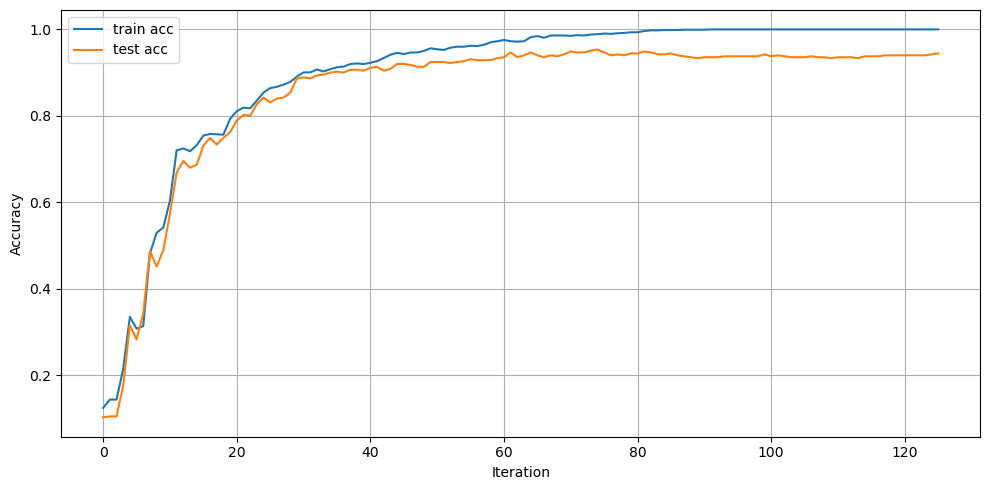

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(cb.train_acc, label="train acc")
ax.plot(cb.test_acc, label="test acc")
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

### `Эксперименты с числом слоев (0.6 балла)`

Ясно, что из-за случайного начального приближения с каждым запуском обучения мы будем получать различное качество. Попробуем обучить нашу нейросеть с разным числом слоев несколько раз.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети с $i+1$ полносвязными слоями при $j$-м запуске (все запуски идентичны).

In [38]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [39]:
### your code here
input_size = X_train.shape[1]
hidden_layers_size = 32
output_size = 10

for i in range(5):
    for j in range(5):
        
        network = make_network(input_size, hidden_layers_size, output_size, i+1, ReLU)
        weights = get_weights(network)

        res = minimize(
            compute_loss_grad,
            weights,
            args=[network, X_train, y_train],
            method="L-BFGS-B",
            jac=True
        )

        set_weights(res.x, network)

        accs_train[i, j] = np.mean(predict(network, X_train) == y_train)
        accs_test[i, j] = np.mean(predict(network, X_test) == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

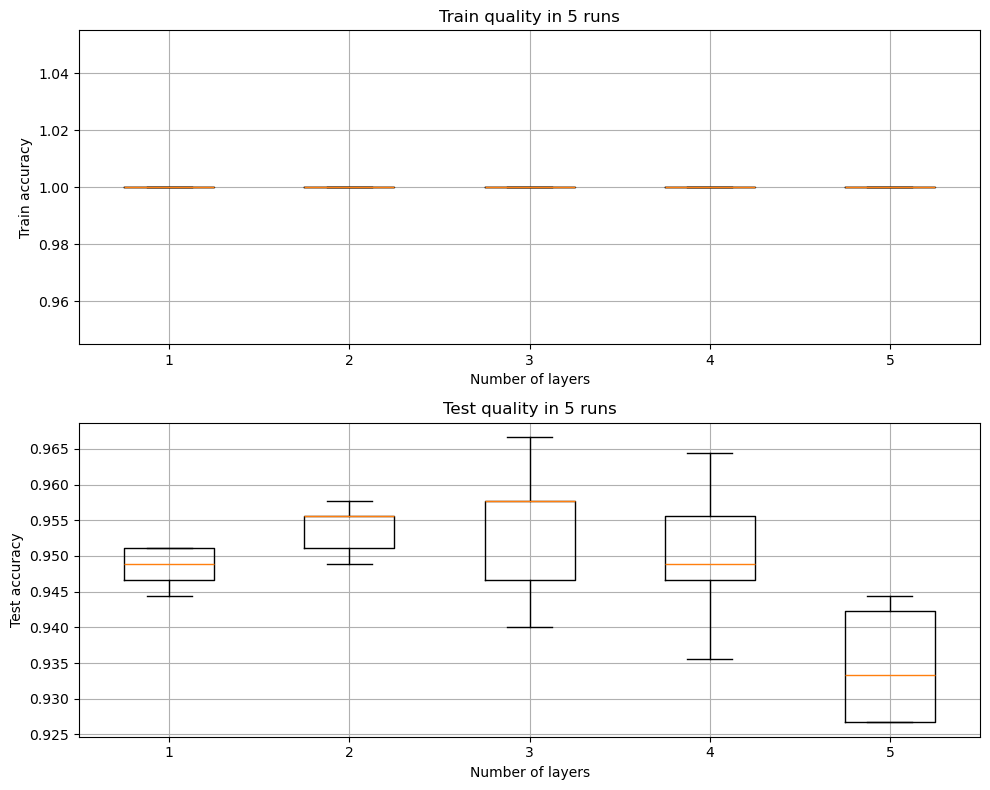

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].boxplot(accs_train.T, showfliers=False)
axes[1].boxplot(accs_test.T, showfliers=False)

axes[0].set_xlabel("Number of layers")
axes[1].set_xlabel("Number of layers")

axes[0].set_ylabel("Train accuracy")
axes[1].set_ylabel("Test accuracy")

axes[0].set_title("Train quality in 5 runs")
axes[1].set_title("Test quality in 5 runs")

axes[0].grid(True)
axes[1].grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как изменяются качество на обучении и контроле и устойчивость процесса обучения при увеличении числа слоев?
* Можно ли сказать, что логистическая регрессия (линейная модель) дает качество хуже, чем нелинейная модель?

__Ответы:__

1. **Качество на обучении.**  
По графику видно, что для всех рассмотренных архитектур качество на обучающей выборке равно примерно **1**. Это означает, что сеть с любым числом слоёв смогла практически полностью подстроиться под обучающую выборку.

2. **Качество на контроле.**
При увеличении числа слоёв качество **не растёт монотонно**.  
- Для небольшого числа слоёв (1–2 слоя) качество достаточно высокое и довольно стабильное.  
- Для 3–4 слоёв качество остаётся сопоставимым, местами даже немного выше, но разброс между запусками становится больше.  
- Для 5 слоёв качество уже заметно хуже, чем у более простых моделей.

3. **Устойчивость обучения.**  
С ростом глубины сети обучение становится **менее устойчивым**: увеличивается разброс качества между разными запусками.

4. **Сравнение логистической регрессии и нелинейных моделей.**  
Однозначно сказать, что логистическая регрессия (модель с одним полносвязным слоем) даёт качество хуже, **нельзя**. По графику видно, что линейная модель показывает качество, сравнимое с более глубокими нелинейными сетями, а в некоторых запусках даже не уступает им.  

### `Эксперименты c различными инициализациями весов (0.6 балла)`

Как уже было сказано, начальная инициализация весов нейронной сети может сильно влиять на процесс ее обучения и, как следствие, на ее качество.

В этом пункте вам предлагается попробовать обучить несколько нейронных сетей с различными инициализациями слоев.

Для этого необходимо реализовать функцию, инициализирующую веса линейных слоёв нашей нейронной сети. Добавьте в функционал данного метода возможность инициализировать его веса с помощью инициализации Kaiming (используется, если в нейронной сети в качестве функций активации используется ReLU) и инициализации Xavier (используется, если в нейронной сети в качестве функций активации используется Tanh или Sigmoid):

In [41]:
def initialize_network(network, initialization):
    for layer in network:
        if isinstance(layer, Dense):
            input_units, output_units = layer.weights.shape
            if initialization == 'Kaiming':
                ### your code here
                layer.weights = np.random.randn(input_units, output_units) * np.sqrt(2 / input_units)
                pass
            elif initialization == 'Xavier':
                ### your code here
                layer.weights = np.random.randn(input_units, output_units) * np.sqrt(2 / (input_units + output_units))
                pass
            else:
                # Initialize weights with small random numbers from normal distribution.
                # In this case `initialization` represents a standard deviation
                # for normal distribution.
                layer.weights = np.random.randn(input_units, output_units) * initialization
            layer.biases = np.zeros_like(layer.biases)
            
            layer.params = [layer.weights, layer.biases]

Теперь попробуйте для каждой из 3 инициализаций обучить нейронную сеть несколько раз. Попробуйте проделать данную операцию при зафиксированном числе слоев равным 3, 4 и 5.

#### `3 слоя`

Зафиксируйте в сети число слоев равное трем.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети при $j$-м запуске (все запуски идентичны) с инициализацией Kaiming при $i = 3$, с инициализацией Xavier при $i = 4$ и с инициализацией из нормального распределения с фиксированными параметрами при $0 \leqslant i \leqslant 2$ (попробуйте здесь 3 разных параметра для стандартного отклонения для нормального распределения, например: `1e-3`, `1e-2`, `1e-1`). Заметьте, что при большом числе слоев слишком низкое стандартное отклонение может не давать нейронной сети нормально обучиться.

In [42]:
init_vars = [1e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [43]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [44]:
### your code here
input_size = X_train.shape[1]
hidden_layers_size = 32
output_size = 10

for i in range(5):
    for j in range(5):
        network = make_network(input_size, hidden_layers_size, output_size, 3, ReLU)

        initialize_network(network, init_vars[i])
        weights = get_weights(network)

        res = minimize(
            compute_loss_grad,
            weights,
            args=[network, X_train, y_train],
            method="L-BFGS-B",
            jac=True
        )

        set_weights(res.x, network)

        accs_train[i, j] = np.mean(predict(network, X_train) == y_train)
        accs_test[i, j] = np.mean(predict(network, X_test) == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

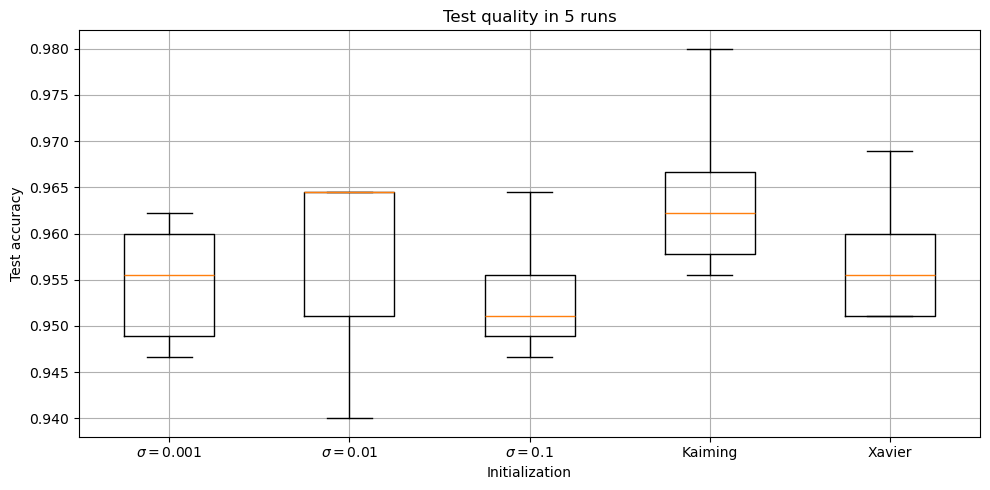

In [45]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, tick_labels=init_vars_for_plot, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

#### `4 слоя`

Выполните тут тот же код, что и в предыдущем пункте, но только уже с 4 слоями в сети.

In [46]:
init_vars = [5e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [47]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [48]:
### your code here
for i in range(5):
    for j in range(5):
        network = make_network(input_size, hidden_layers_size, output_size, 4, ReLU)

        initialize_network(network, init_vars[i])
        weights = get_weights(network)

        res = minimize(
            compute_loss_grad,
            weights,
            args=[network, X_train, y_train],
            method="L-BFGS-B",
            jac=True
        )

        set_weights(res.x, network)

        accs_train[i, j] = np.mean(predict(network, X_train) == y_train)
        accs_test[i, j] = np.mean(predict(network, X_test) == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

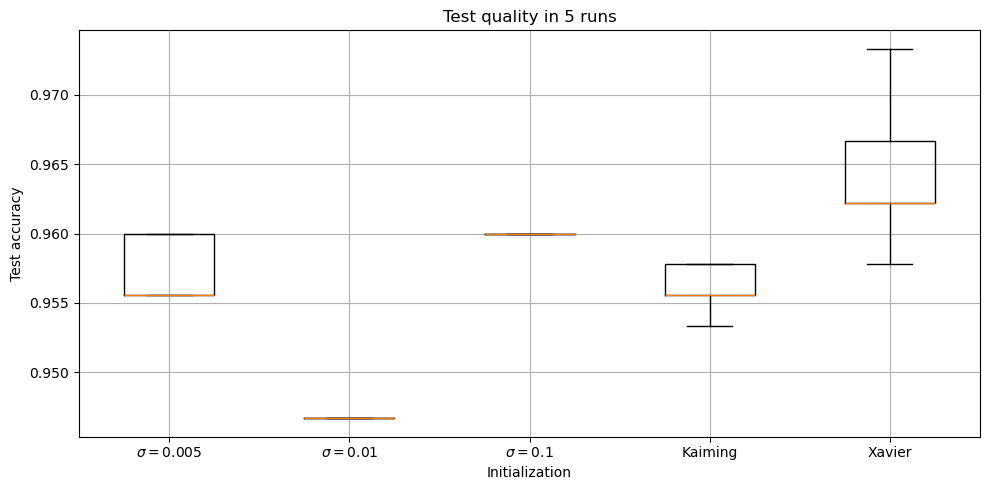

In [49]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, tick_labels=init_vars_for_plot, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

#### `5 слоев`

Выполните тут тот же код, что и в предыдущем пункте, но только уже с 5 слоями в сети.

In [50]:
init_vars = [1e-2, 1e-1, 1e0, 'Kaiming', 'Xavier']

In [51]:
accs_train = np.zeros((5, 5))
accs_test = np.zeros((5, 5))

In [52]:
### your code here
for i in range(5):
    for j in range(5):
        network = make_network(input_size, hidden_layers_size, output_size, 5, ReLU)

        initialize_network(network, init_vars[i])
        weights = get_weights(network)

        res = minimize(
            compute_loss_grad,
            weights,
            args=[network, X_train, y_train],
            method="L-BFGS-B",
            jac=True
        )

        set_weights(res.x, network)

        accs_train[i, j] = np.mean(predict(network, X_train) == y_train)
        accs_test[i, j] = np.mean(predict(network, X_test) == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

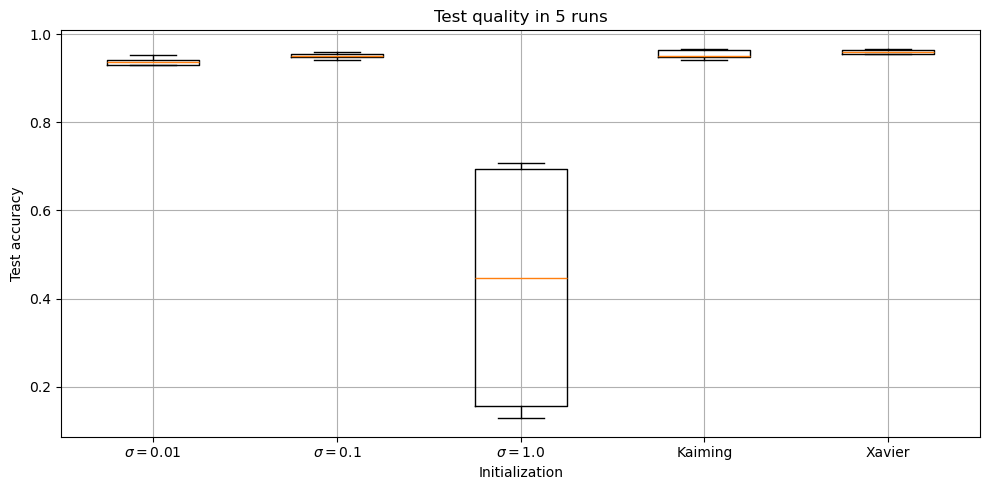

In [53]:
init_vars_for_plot = [(x if isinstance(x, str) else fr"$\sigma = {x}$") for x in init_vars]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, tick_labels=init_vars_for_plot, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Initialization")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как отличаются качество на обучении и контроле и устойчивость процесса обучения при различных инициализациях?
* Какие инициализации помогают обучать более глубокие сети?

__Ответы:__

1. **Качество и устойчивость при разных инициализациях.**  
По трём графикам 2-3 видно, что инициализация $ \sigma = 0.001 $ даёт худший результат: качество очень низкое и на обучении, и на контроле, сеть практически не обучается.  
Инициализации $ \sigma = 0.01 $ и $ \sigma = 0.1 $ работают заметно лучше. При $ \sigma = 0.1 $ качество обычно выше, чем при $ \sigma = 0.01 $.  
Инициализации **Kaiming** и **Xavier** дают лучшие результаты на контроле, первый в случае 1 уровня, второй в остальных случаях.У них выше медиана качества и в целом обучение проходит устойчивее. На графиках лучше выглядит **Xavier**.

2. **Какие инициализации помогают обучать более глубокие сети.**  
Судя по графикам, для более глубоких сетей лучше подходят **Kaiming** и **Xavier**, так как именно они дают наиболее высокое качество.  
Инициализация с очень маленьким стандартным отклонением $ \sigma = 0.001 $ для глубоких сетей явно не подходит, поскольку обучение почти не происходит.  
Инициализации $ \sigma = 0.01 $ и $ \sigma = 0.1 $ могут работать.

Теперь сравним скорость обучения при различных инициализациях. Создайте два списка списков `accs_test_on_iterations`, `accs_train_on_iterations` в каждом из которых в позиции `[i]` (см. описание `i` в предыдущем пункте) будет лежать список из значений `accuracy` на тестовой и обучающей выборках соотвественно, полученных во время обучения модели. Количество слоев в сети зафиксируйте равным 4.

In [54]:
init_vars = [1e-3, 1e-2, 1e-1, 'Kaiming', 'Xavier']

In [55]:
accs_test_on_iterations = []
accs_train_on_iterations = []

In [56]:
### your code here
for i in range(5):
    network = make_network(input_size, hidden_layers_size, output_size, 4, ReLU)
    initialize_network(network, init_vars[i])
    weights = get_weights(network)

    cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

    res = minimize(
        compute_loss_grad,
        weights,
        args=[network, X_train, y_train],
        method="L-BFGS-B",
        jac=True,
        callback=cb.call
    )

    accs_train_on_iterations.append(cb.train_acc)
    accs_test_on_iterations.append(cb.test_acc)

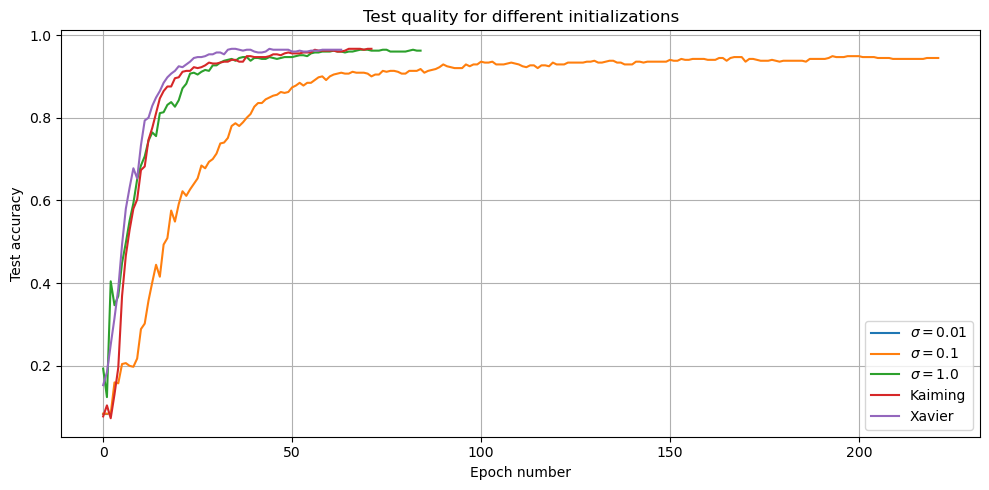

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for idx, label in enumerate(init_vars_for_plot):
    ax.plot(accs_test_on_iterations[idx], label=label)

ax.set_title("Test quality for different initializations")
ax.set_xlabel("Epoch number")
ax.set_ylabel("Test accuracy")
ax.grid(True)
ax.legend()

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как меняется скорость обучения в зависимости от выбранной инициализации?

__Ответы:__

- **Xavier** обучается быстрее всех: качество растёт наиболее резко в первые итерации и раньше выходит на высокий уровень.
- **Kaiming** с **$\sigma = 0.1$** тоже дают быстрое обучение, но немного уступают Xavier по скорости роста.
- Инициализация  обучается достаточно быстро, но всё же медленнее, чем Xavier и Kaiming.
- Инициализация с **$\sigma = 0.01$** обучается заметно медленнее остальных: качество растёт более плавно и достигает высокого уровня существенно позже.
- Для **$\sigma = 0.001$** по графику не видно, то есть обучение не происходит.

Итак, по скорости обучения лучшие результаты показывают **Xavier** , а слишком маленькая инициализация существенно замедляет или срывает обучение.

### `Эксперименты c различными функциями активации (0.6 балла)`

Проверим теперь, с какой функцией активации нейронная сеть будет обучаться лучше.

В этом пункте вам предлагается попробовать обучить несколько нейронных сетей с различными функциями активации.

Для этого нам нужно реализовать еще 2 слоя: для функций активации `Tanh` и `Sigmoid`.

In [58]:
class Tanh:
    """
    tanh(y) = (e^y - e^(-y)) / (e^y + e^(-y))
    Используйте функцию np.tanh для подсчета гиперболического тангенса.
    Вы можете сами реализовать подсчет tanh, но тогда вам нужно устойчиво его вычислять.
    """
    def __init__(self):
        self.params = [] # Tanh has no parameters

    def forward(self, input):
        """
        Apply elementwise Tanh to [batch, num_units] matrix
        """
        ### your code here
        self.input = input
        self.output = np.tanh(input)
        return self.output 

    def backward(self, grad_output):
        """
        Compute gradient of loss w.r.t. Tanh input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        ### your code here
        grad_input = grad_output * (1 - self.output ** 2)
        return grad_input, []

    def __repr__(self):
        return 'Tanh()'

In [59]:
from scipy.special import expit
    
class Sigmoid:
    """
    sigmoid(y) = 1 / (1 + e^(-y))
    Используйте функцию expit для подсчета сигмоиды.
    Вы можете сами реализовать подсчет сигмоиды, но тогда вам нужно устойчиво ее вычислять.
    """
    def __init__(self):
        self.params = [] # Sigmoid has no parameters

    def forward(self, input):
        """
        Apply elementwise Sigmoid to [batch, num_units] matrix
        """
        ### your code here
        self.input = input
        self.output = expit(input)
        return self.output

    def backward(self, grad_output):
        """
        Compute gradient of loss w.r.t. Sigmoid input
        grad_output shape: [batch, num_units]
        output 1 shape: [batch, num_units]
        output 2: []
        """
        ### your code here
        grad_input = grad_output * self.output * (1 - self.output)
        return grad_input, []

    def __repr__(self):
        return 'Sigmoid()'

Теперь попробуйте для каждой из 3 функций активации обучить нейронную сеть несколько раз. Число слоев зафиксируйте равным 3. В случае `Tanh` и `Sigmoid` используйте инициализацию `Xavier`, а в случае `ReLU` используйте инициализацию `Kaiming`.

Заполните матрицы `accs_train` и `accs_test`. В позиции `[i, j]` должна стоять величина доли правильных ответов сети при $j$-м запуске (все запуски идентичны) с функцией активации $ReLU$ при $i = 0$, с функцией активации $Tanh$ при $i = 1$ и с функцией активации $Sigmoid$ при $i = 2$.

In [60]:
act_func_vars = ['Tanh', 'Sigmoid', 'ReLU']
init_for_act_funcs = ['Xavier', 'Xavier', 'Kaiming']

In [61]:
accs_train = np.zeros((3, 5))
accs_test = np.zeros((3, 5))

In [62]:
### your code here
act_classes = [Tanh, Sigmoid, ReLU]

for i in range(3):
    for j in range(5):
        network = make_network(
            input_size=input_size,
            hidden_layers_size=hidden_layers_size,
            output_size=output_size,
            n_layers=3,
            activation_class=act_classes[i]
        )

        initialize_network(network, init_for_act_funcs[i])
        weights = get_weights(network)

        res = minimize(
            compute_loss_grad,
            weights,
            args=[network, X_train, y_train],
            method="L-BFGS-B",
            jac=True
        )

        set_weights(res.x, network)

        accs_train[i, j] = np.mean(predict(network, X_train) == y_train)
        accs_test[i, j] = np.mean(predict(network, X_test) == y_test)

Построим боксплоты полученного качества (горизонтальная линия в каждом столбце — среднее, прямоугольник показывает разброс).

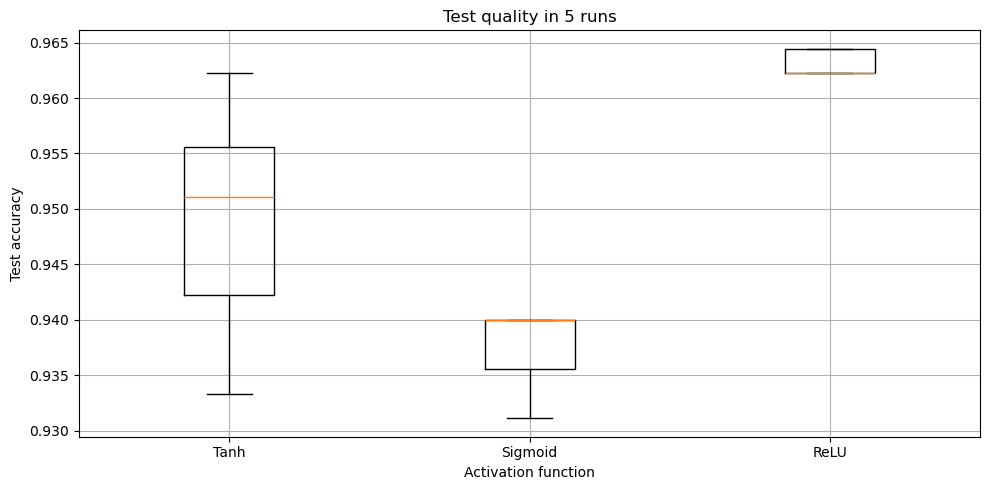

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.boxplot(accs_test.T, tick_labels=act_func_vars, showfliers=False)

ax.set_title("Test quality in 5 runs")
ax.set_xlabel("Activation function")
ax.set_ylabel("Test accuracy")
ax.grid(True)

fig.tight_layout()
plt.show()

Дайте развёрнутый ответ на вопросы (в этой же ячейке):
* Как отличаются качество на обучении и контроле и устойчивость процесса обучения при различных функциях активации?

__Ответы:__

По графику видно, что наилучшее качество на контроле показывает сеть с функцией активации **ReLU**: у неё самая высокая медиана accuracy и в целом результаты по запускам выше и стабильней, чем у остальных.  
**Sigmoid** даёт более низкое качество, но результаты при этом стабильны.  
**Tanh** показывает качество ниже, чем ReLU, устойчивость обучения низкая.

\* Несколько фрагментов кода в задании написаны на основе материалов [курса по глубинному обучению на ФКН НИУ ВШЭ](https://www.hse.ru/ba/ami/courses/205504078.html)

### `Реализация метода оптимизации (1.4 балла)`

В этой части задания реализуйте метод оптимизации SGD + momentum. Упрощённая версия более общего алгоритма [отсюда](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html):

$$
\begin{aligned}
    &\rule{70mm}{0.4pt}                                                             \\
    &\textbf{input}      : \gamma \text{ (lr)}, \: \theta_0 \text{ (params)}, \: X \text{ (data)},       \\
    &\hspace{13mm} \: f(\theta) \text{ (objective)}, \:\mu \text{ (momentum)}       \\[-1.ex]
    &\rule{70mm}{0.4pt}                                                             \\
    &\textbf{for} \: t=1 \: \textbf{to} \: \ldots \: \textbf{do}                    \\
    &\hspace{5mm}\mathcal{X} \leftarrow \texttt{list\_of\_random\_batches}(X)\\
    &\hspace{5mm}\textbf{for} \: i=1 \: \textbf{to} \: \ldots \: \textbf{do}                    \\
    &\hspace{10mm}g_t\leftarrow   \nabla_{\theta} f_t (\theta_{t-1},\mathcal{X}_i)      \\
    &\hspace{10mm}\textbf{if} \: \mu \neq 0                                          \\
    &\hspace{15mm}\textbf{if} \: t > 1                                              \\
    &\hspace{20mm} \textbf{b}_t \leftarrow \mu \textbf{b}_{t-1} + g_t               \\
    &\hspace{15mm}\textbf{else}                                                     \\
    &\hspace{20mm} \textbf{b}_t \leftarrow g_t                                      \\
    &\hspace{15mm} g_t  \leftarrow  \textbf{b}_t                                     \\
    &\hspace{10mm}\theta_t \leftarrow \theta_{t-1} - \gamma g_t                      \\[-1.ex]
    &\rule{70mm}{0.4pt}                                                             \\[-1.ex]
    &\bf{return} \:  \theta_t                                                       \\[-1.ex]
    &\rule{70mm}{0.4pt}                                                             \\[-1.ex]
\end{aligned}
$$

Проще всего будет написать `custom minimizer` (смотри [документацию scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)).

In [64]:
from scipy.optimize import OptimizeResult


def SGD(fun, x0, args, **kwargs) -> OptimizeResult:
    callback = kwargs['callback']   # feed weights from each iteration to update network and log metrics
    mu = kwargs['momentum']
    n_iter = kwargs['n_iter']
    gamma = kwargs['lr']
    jac = kwargs['jac']
    batch_size = kwargs['batch_size']

    net, X, y = args
    
    # your code is here

    weights = np.array(x0, copy=True)
    velocity = np.zeros_like(weights)

    n_objects = X.shape[0]
    loss = None
    grad = None

    for _ in range(n_iter):
        perm = np.random.permutation(n_objects)
        X_shuffled = X[perm]
        y_shuffled = y[perm]

        for start in range(0, n_objects, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            loss, grad = fun(weights, [net, X_batch, y_batch])

            if mu != 0:
                velocity = mu * velocity + grad
                grad_step = velocity
            else:
                grad_step = grad

            weights = weights - gamma * grad_step

        if callback is not None:
            callback(weights)

    loss, grad = fun(weights, [net, X, y])

    return OptimizeResult(
        x=weights,
        fun=loss,
        jac=grad,
        nit=n_iter,
        success=True
    )

**Задание 1. (0.5 балла)** Продемонстрируйте правильную работу метода оптимизации, получив `test_accuracy>=0.9`.

In [65]:
# your code is here
network = make_network(
    input_size=X_train.shape[1],
    hidden_layers_size=32,
    output_size=10,
    n_layers=3,
    activation_class=ReLU
)

initialize_network(network, 'Kaiming')
weights = get_weights(network)

cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

res = minimize(
    compute_loss_grad,
    weights,
    args=(network, X_train, y_train),
    method=SGD,
    jac=False,
    callback=cb.call,
    options={
        'lr': 0.01,
        'momentum': 0.9,
        'n_iter': 30,
        'batch_size': 128
    }
)

set_weights(res.x, network)

train_acc = np.mean(predict(network, X_train) == y_train)
test_acc = np.mean(predict(network, X_test) == y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)



Train accuracy: 0.9762435040831478
Test accuracy: 0.9266666666666666


**Задание 2. (0.8 балла)** Сравните три алгоритма:
1. LBFGS-B
2. SGD
3. SGD + momentum

Для этого одновременно переберите следующие гиперпараметры:
- значения `lr` на отрезке `[1e-3, 1e-1]` по логарифмической сетке
- два значения `momentum`: `0` и `0.9`
- значения `batch_size`: `8` и `32`

В каждом запуске сохраняйте три метрики: итоговое accuracy на тесте и на трейне и время обучения.

Для каждого из трёх алгоритмов выберите лучшие `lr` и `batch_size` по `test_accuracy`. Постройте для них кривые обучения (пример ниже). Сделайте выводы.

![](comparison.svg)

In [66]:
# your code is here
import time

lrs = np.logspace(-3, -1, 5)
batch_sizes = [8, 32]

def run_lbfgs():
    network = make_network(X_train.shape[1], 32, 10, 3, ReLU)
    initialize_network(network, 'Kaiming')
    weights = get_weights(network)
    cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

    t0 = time.time()
    res = minimize(
        compute_loss_grad,
        weights,
        args=[network, X_train, y_train],
        method='L-BFGS-B',
        jac=True,
        callback=cb.call
    )
    dt = time.time() - t0

    set_weights(res.x, network)
    return {
        'algo': 'LBFGS-B',
        'lr': None,
        'batch_size': None,
        'train_acc': np.mean(predict(network, X_train) == y_train),
        'test_acc': np.mean(predict(network, X_test) == y_test),
        'time': dt,
        'train_curve': cb.train_acc,
        'test_curve': cb.test_acc
    }

def run_sgd(mu, lr, bs):
    network = make_network(X_train.shape[1], 32, 10, 3, ReLU)
    initialize_network(network, 'Kaiming')
    weights = get_weights(network)
    cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

    t0 = time.time()
    res = SGD(
        compute_loss_grad,
        weights,
        args=[network, X_train, y_train],
        callback=cb.call,
        momentum=mu,
        n_iter=40,
        lr=lr,
        jac=True,
        batch_size=bs
    )
    dt = time.time() - t0

    set_weights(res.x, network)
    return {
        'algo': 'SGD' if mu == 0 else 'SGD+momentum',
        'lr': lr,
        'batch_size': bs,
        'train_acc': np.mean(predict(network, X_train) == y_train),
        'test_acc': np.mean(predict(network, X_test) == y_test),
        'time': dt,
        'train_curve': cb.train_acc,
        'test_curve': cb.test_acc
    }

results = [run_lbfgs()]
for mu in [0, 0.9]:
    for lr in lrs:
        for bs in batch_sizes:
            results.append(run_sgd(mu, lr, bs))

In [67]:
best = []
for algo in ['LBFGS-B', 'SGD', 'SGD+momentum']:
    cur = [r for r in results if r['algo'] == algo]
    best.append(max(cur, key=lambda r: r['test_acc']))

for r in best:
    print(r['algo'], 'lr =', r['lr'], 'batch_size =', r['batch_size'],
          'train_acc =', r['train_acc'], 'test_acc =', r['test_acc'], 'time =', r['time'])

LBFGS-B lr = None batch_size = None train_acc = 1.0 test_acc = 0.9555555555555556 time = 0.1683948040008545
SGD lr = 0.01 batch_size = 8 train_acc = 1.0 test_acc = 0.9666666666666667 time = 1.7753489017486572
SGD+momentum lr = 0.0031622776601683794 batch_size = 8 train_acc = 1.0 test_acc = 0.9733333333333334 time = 1.7524728775024414


**Выводы:**

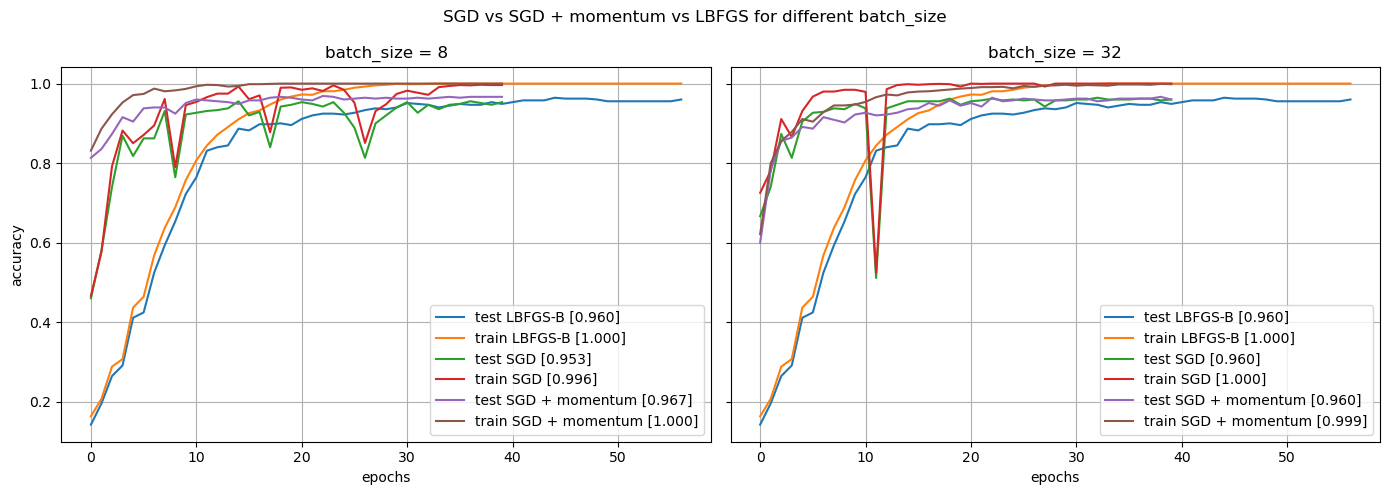

In [68]:
best_lr_sgd = 0.03162277660168379
best_lr_mom = 0.001

lbfgs = run_lbfgs()

sgd_8 = run_sgd(0, best_lr_sgd, 8)
sgd_32 = run_sgd(0, best_lr_sgd, 32)

mom_8 = run_sgd(0.9, best_lr_mom, 8)
mom_32 = run_sgd(0.9, best_lr_mom, 32)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

curves = [
    ('LBFGS-B', lbfgs, lbfgs),
    ('SGD', sgd_8, sgd_32),
    ('SGD + momentum', mom_8, mom_32),
]

for ax, bs, idx in zip(axes, [8, 32], [0, 1]):
    for name, res8, res32 in curves:
        res = res8 if idx == 0 else res32
        ax.plot(res['test_curve'], label=f'test {name} [{res["test_acc"]:.3f}]')
        ax.plot(res['train_curve'], label=f'train {name} [{res["train_acc"]:.3f}]')
    ax.set_title(f'batch_size = {bs}')
    ax.set_xlabel('epochs')
    ax.grid(True)
    ax.legend()

axes[0].set_ylabel('accuracy')
plt.suptitle('SGD vs SGD + momentum vs LBFGS for different batch_size')
plt.tight_layout()
plt.show()

**Задание 3. (0.1 балла)** Для отобранных в прошлом задании трёх алгоритмов ответье на вопрос: как меняются запуски для двух значений `batch_size`.

**Ответ:**

По графикам видно следующее.

- Для **LBFGS-B** изменение `batch_size` ничего не меняет: кривые при `batch_size = 8` и `batch_size = 32` совпадают, так как метод использует всю выборку целиком. Оптимизация долгая.
- Для **SGD** в данном эксперименте `batch_size = 8` оказался лучше: итоговое качество на тесте выше (`0.971` против `0.953`), и хорошее качество достигается быстрее. Так же более стабильное обучение оказалось при `batch_size = 8`
- Для **SGD + momentum** картина такая же: при `batch_size = 8` качество на тесте выше (`0.962` против `0.951`), чем при `batch_size = 32`. Обучение стабильное (при 32 чуть более стабильное)

Итак, в этом эксперименте уменьшение `batch_size` с `32` до `8` улучшило качество для стохастических методов (**SGD** и **SGD + momentum**), а для **LBFGS-B** размер батча роли не играет.

## `Бонусная часть`

### `Реализация метода оптимизации (1 балл)`

Реализуйте метод оптимизации Adam и сравните его работу с SGD + momentum, проведя эксперимент, как в задании 2 (перебор гиперпараметров + кривые обучения).

In [69]:
def Adam(fun, x0, args, **kwargs) -> OptimizeResult:
    callback = kwargs['callback']
    n_iter = kwargs['n_iter']
    gamma = kwargs['lr']
    batch_size = kwargs['batch_size']
    beta1 = kwargs.get('beta1', 0.9)
    beta2 = kwargs.get('beta2', 0.999)
    eps = kwargs.get('eps', 1e-8)

    net, X, y = args

    weights = np.array(x0, copy=True)
    m = np.zeros_like(weights)
    v = np.zeros_like(weights)

    n_objects = X.shape[0]
    t = 0
    loss = None
    grad = None

    for _ in range(n_iter):
        perm = np.random.permutation(n_objects)
        X_shuffled = X[perm]
        y_shuffled = y[perm]

        for start in range(0, n_objects, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            loss, grad = fun(weights, [net, X_batch, y_batch])

            t += 1
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad ** 2)

            m_hat = m / (1 - beta1 ** t)
            v_hat = v / (1 - beta2 ** t)

            weights = weights - gamma * m_hat / (np.sqrt(v_hat) + eps)

        if callback is not None:
            callback(weights)

    loss, grad = fun(weights, [net, X, y])

    return OptimizeResult(
        x=weights,
        fun=loss,
        jac=grad,
        nit=n_iter,
        success=True
    )

In [70]:
lrs = np.logspace(-3, -1, 5)
batch_sizes = [8, 32]

def run_adam(lr, bs):
    network = make_network(X_train.shape[1], 32, 10, 4, ReLU)
    initialize_network(network, 'Kaiming')
    weights = get_weights(network)
    cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

    t0 = time.time()
    res = Adam(
        compute_loss_grad,
        weights,
        args=[network, X_train, y_train],
        callback=cb.call,
        n_iter=40,
        lr=lr,
        batch_size=bs
    )
    dt = time.time() - t0

    set_weights(res.x, network)
    return {
        'algo': 'Adam',
        'lr': lr,
        'batch_size': bs,
        'train_acc': np.mean(predict(network, X_train) == y_train),
        'test_acc': np.mean(predict(network, X_test) == y_test),
        'time': dt,
        'train_curve': cb.train_acc,
        'test_curve': cb.test_acc
    }

adam_results = []
sgd_mom_results = []

for lr in lrs:
    for bs in batch_sizes:
        adam_results.append(run_adam(lr, bs))
        sgd_mom_results.append(run_sgd(0.9, lr, bs))

best_adam = max(adam_results, key=lambda r: r['test_acc'])
best_sgd_mom = max(sgd_mom_results, key=lambda r: r['test_acc'])

print('Adam:', best_adam['lr'], best_adam['batch_size'],
      best_adam['train_acc'], best_adam['test_acc'], best_adam['time'])

print('SGD + momentum:', best_sgd_mom['lr'], best_sgd_mom['batch_size'],
      best_sgd_mom['train_acc'], best_sgd_mom['test_acc'], best_sgd_mom['time'])

Adam: 0.01 32 0.9970304380103935 0.98 0.7173714637756348
SGD + momentum: 0.0031622776601683794 8 1.0 0.9666666666666667 1.8170173168182373


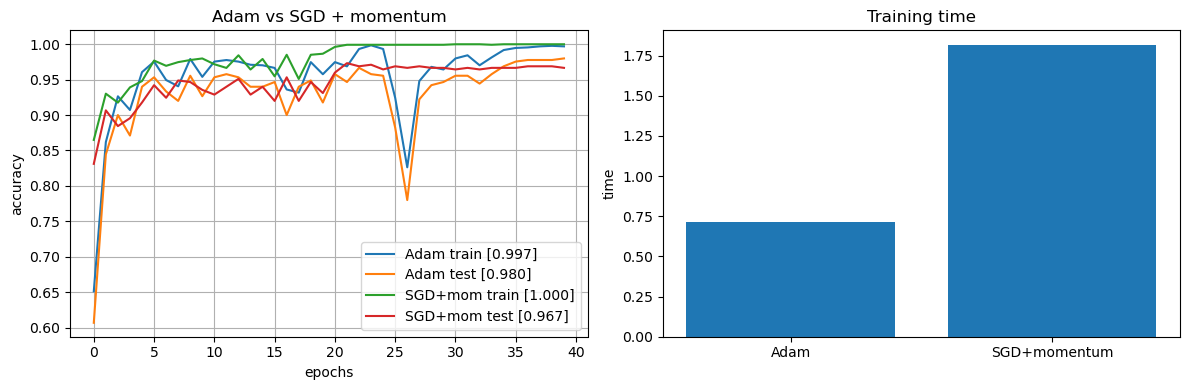

In [71]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_adam['train_curve'], label=f"Adam train [{best_adam['train_acc']:.3f}]")
plt.plot(best_adam['test_curve'], label=f"Adam test [{best_adam['test_acc']:.3f}]")
plt.plot(best_sgd_mom['train_curve'], label=f"SGD+mom train [{best_sgd_mom['train_acc']:.3f}]")
plt.plot(best_sgd_mom['test_curve'], label=f"SGD+mom test [{best_sgd_mom['test_acc']:.3f}]")
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Adam vs SGD + momentum')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.bar(
    ['Adam', 'SGD+momentum'],
    [best_adam['time'], best_sgd_mom['time']]
)
plt.ylabel('time')
plt.title('Training time')

plt.tight_layout()
plt.show()

### `Dropout (1 балл)`

Реализуйте слой Dropout. Сравните обучение сети из большого числа слоёв при использовании Dropout и без его использования (предварительно подберите адекватный параметр $p$). Сделайте выводы.

In [72]:
class Dropout:
    def __init__(self, p=0.5):
        self.p = p
        self.params = []
        self.training = True

    def forward(self, input):
        if not self.training:
            return input
        self.mask = (np.random.rand(*input.shape) > self.p) / (1 - self.p)
        return input * self.mask

    def backward(self, grad_output):
        if not self.training:
            return grad_output, []
        return grad_output * self.mask, []

    def __repr__(self):
        return f'Dropout(p={self.p})'


def set_training(network, training=True):
    for layer in network:
        if isinstance(layer, Dropout):
            layer.training = training

In [73]:
# добавления training

def predict(network, X):
    set_training(network, False)
    y = np.argmax(forward(network, X), axis=1)
    set_training(network, True)
    return y


def compute_loss_grad(weights, args):
    network, X, y = args

    set_weights(weights, network)
    set_training(network, True)

    activations = forward(network, X)
    loss = NLL(activations, y)
    grad_output = grad_NLL(activations, y)

    layer_grads = []
    for layer in network[::-1]:
        grad_output, grad_params = layer.backward(grad_output)
        layer_grads.append(grad_params)

    layer_grads = layer_grads[::-1]
    flat_grads = np.r_[tuple(layer_grads)] if len(layer_grads) > 0 else np.array([])

    return loss, flat_grads

Без Dropout: 0.4239049740163326 0.38222222222222224
С Dropout: 0.10616184112843356 0.08444444444444445


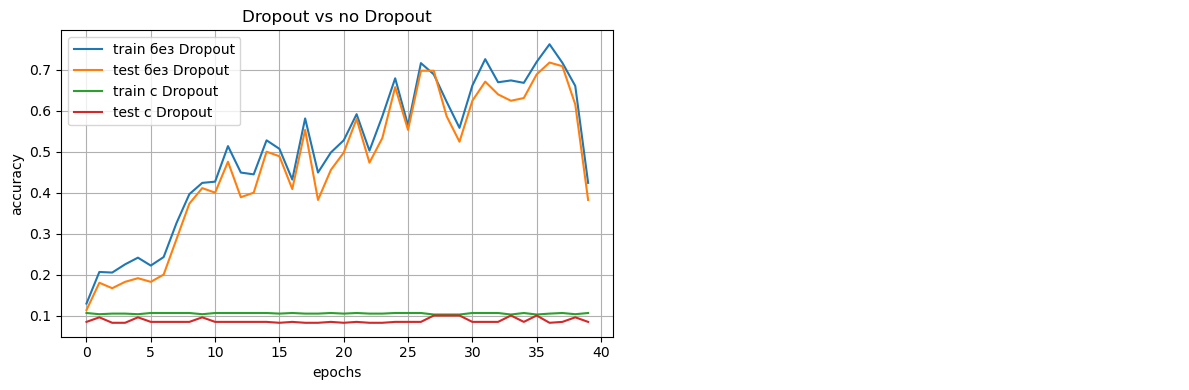

In [74]:
def make_network_dropout(input_size, hidden_layers_size, output_size, n_layers=4, p=0.2):
    network = [Dense(input_size, hidden_layers_size), ReLU()]
    for _ in range(n_layers - 2):
        network += [Dense(hidden_layers_size, hidden_layers_size), ReLU(), Dropout(p)]
    network += [Dense(hidden_layers_size, output_size), LogSoftmax()]
    return network


def train_net(network):
    initialize_network(network, 'Kaiming')
    weights = get_weights(network)
    cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

    res = SGD(
        compute_loss_grad,
        weights,
        args=[network, X_train, y_train],
        callback=cb.call,
        momentum=0.9,
        n_iter=40,
        lr=0.01,
        jac=True,
        batch_size=32
    )

    set_weights(res.x, network)
    return cb


net_no_dropout = make_network(X_train.shape[1], 8, 10, n_layers=10, activation_class=ReLU)
net_dropout = make_network_dropout(X_train.shape[1], 8, 10, n_layers=10, p=0.1)

cb_no = train_net(net_no_dropout)
cb_do = train_net(net_dropout)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(cb_no.train_acc, label='train без Dropout')
plt.plot(cb_no.test_acc, label='test без Dropout')
plt.plot(cb_do.train_acc, label='train с Dropout')
plt.plot(cb_do.test_acc, label='test с Dropout')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Dropout vs no Dropout')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
print('Без Dropout:',
      np.mean(predict(net_no_dropout, X_train) == y_train),
      np.mean(predict(net_no_dropout, X_test) == y_test))
print('С Dropout:',
      np.mean(predict(net_dropout, X_train) == y_train),
      np.mean(predict(net_dropout, X_test) == y_test))
plt.axis('off')

plt.tight_layout()
plt.show()

Здесь была глубокая сеть но с малым числом параметров 8*10, без Dropout сеть не обучалась.

### `BatchNormalization (1 балл)`

Реализуйте слой `BatchNormalization`. Сравните обучение сети из большого числа слоёв при использовании `BatchNormalization` и без его использования. Сделайте выводы.

In [75]:
class BatchNormalization:
    def __init__(self, num_features, eps=1e-5, momentum=0.9):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = np.ones(num_features)
        self.beta = np.zeros(num_features)
        self.params = [self.gamma, self.beta]

        self.running_mean = np.zeros(num_features)
        self.running_var = np.ones(num_features)

    def forward(self, input):
        if self.training:
            self.input = input
            self.mean = input.mean(axis=0)
            self.var = input.var(axis=0)

            self.x_hat = (input - self.mean) / np.sqrt(self.var + self.eps)
            output = self.gamma * self.x_hat + self.beta

            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * self.mean
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * self.var
            return output
        else:
            x_hat = (input - self.running_mean) / np.sqrt(self.running_var + self.eps)
            return self.gamma * x_hat + self.beta

    def backward(self, grad_output):
        n = grad_output.shape[0]

        grad_gamma = np.sum(grad_output * self.x_hat, axis=0)
        grad_beta = np.sum(grad_output, axis=0)

        dx_hat = grad_output * self.gamma
        std_inv = 1 / np.sqrt(self.var + self.eps)

        grad_input = (1 / n) * std_inv * (
            n * dx_hat
            - np.sum(dx_hat, axis=0)
            - self.x_hat * np.sum(dx_hat * self.x_hat, axis=0)
        )

        return grad_input, np.r_[grad_gamma.ravel(), grad_beta.ravel()]

    def __repr__(self):
        return f'BatchNormalization({self.gamma.shape[0]})'


In [76]:
# Сеть без Dropout, но с BatchNorm
def make_network_bn(input_size, hidden_layers_size, output_size, n_layers=10):
    network = [Dense(input_size, hidden_layers_size), BatchNormalization(hidden_layers_size), ReLU()]
    for _ in range(n_layers - 2):
        network += [
            Dense(hidden_layers_size, hidden_layers_size),
            BatchNormalization(hidden_layers_size),
            ReLU()
        ]
    network += [Dense(hidden_layers_size, output_size), LogSoftmax()]
    return network


# Сеть с Dropout и BatchNorm
def make_network_dropout_bn(input_size, hidden_layers_size, output_size, n_layers=10, p=0.1):
    network = [Dense(input_size, hidden_layers_size), BatchNormalization(hidden_layers_size), ReLU()]
    for _ in range(n_layers - 2):
        network += [
            Dense(hidden_layers_size, hidden_layers_size),
            BatchNormalization(hidden_layers_size),
            ReLU(),
            Dropout(p)
        ]
    network += [Dense(hidden_layers_size, output_size), LogSoftmax()]
    return network


def train_net(network, lr=0.01, momentum=0.9, n_iter=40, batch_size=32):
    initialize_network(network, 'Kaiming')
    weights = get_weights(network)
    cb = Callback(network, X_train, y_train, X_test, y_test, print=False)

    res = SGD(
        compute_loss_grad,
        weights,
        args=[network, X_train, y_train],
        callback=cb.call,
        momentum=momentum,
        n_iter=n_iter,
        lr=lr,
        jac=True,
        batch_size=batch_size
    )

    set_weights(res.x, network)
    return cb, res


# 4 сети: без Dropout / с Dropout, без BN / с BN
net_no_dropout = make_network(X_train.shape[1], 16, 10, n_layers=15, activation_class=ReLU)
net_dropout = make_network_dropout(X_train.shape[1], 16, 10, n_layers=15, p=0.2)

net_no_dropout_bn = make_network_bn(X_train.shape[1], 16, 10, n_layers=15)
net_dropout_bn = make_network_dropout_bn(X_train.shape[1], 16, 10, n_layers=15, p=0.2)

cb_no_dropout, _ = train_net(net_no_dropout)
cb_dropout, _ = train_net(net_dropout)
cb_no_dropout_bn, _ = train_net(net_no_dropout_bn)
cb_dropout_bn, _ = train_net(net_dropout_bn)

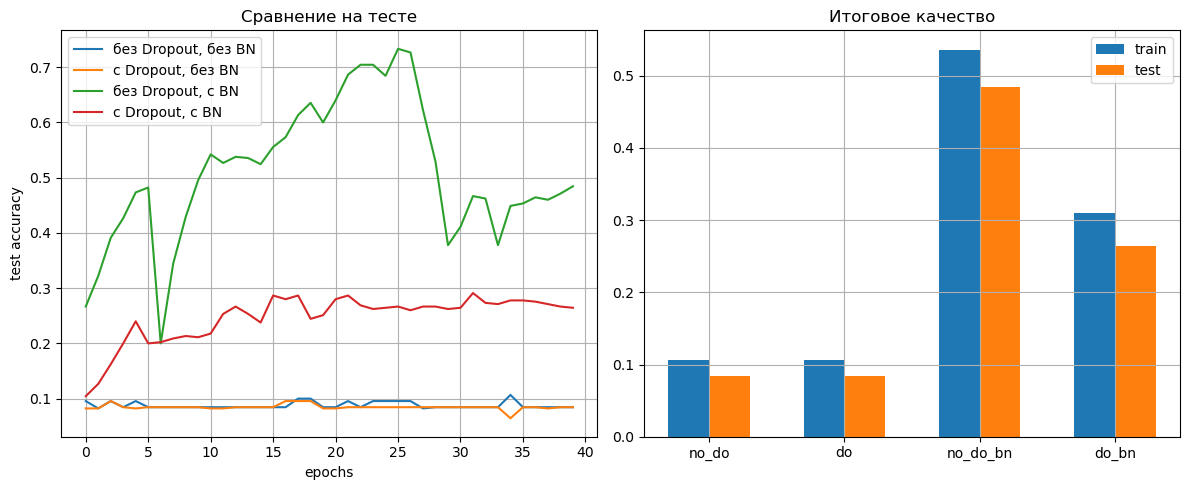

In [77]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cb_no_dropout.test_acc, label='без Dropout, без BN')
plt.plot(cb_dropout.test_acc, label='с Dropout, без BN')
plt.plot(cb_no_dropout_bn.test_acc, label='без Dropout, с BN')
plt.plot(cb_dropout_bn.test_acc, label='с Dropout, с BN')
plt.xlabel('epochs')
plt.ylabel('test accuracy')
plt.title('Сравнение на тесте')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
names = ['no_do', 'do', 'no_do_bn', 'do_bn']
train_accs = [
    np.mean(predict(net_no_dropout, X_train) == y_train),
    np.mean(predict(net_dropout, X_train) == y_train),
    np.mean(predict(net_no_dropout_bn, X_train) == y_train),
    np.mean(predict(net_dropout_bn, X_train) == y_train),
]
test_accs = [
    np.mean(predict(net_no_dropout, X_test) == y_test),
    np.mean(predict(net_dropout, X_test) == y_test),
    np.mean(predict(net_no_dropout_bn, X_test) == y_test),
    np.mean(predict(net_dropout_bn, X_test) == y_test),
]

x = np.arange(len(names))
plt.bar(x - 0.15, train_accs, width=0.3, label='train')
plt.bar(x + 0.15, test_accs, width=0.3, label='test')
plt.xticks(x, names)
plt.title('Итоговое качество')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()